In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import *
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f
import random

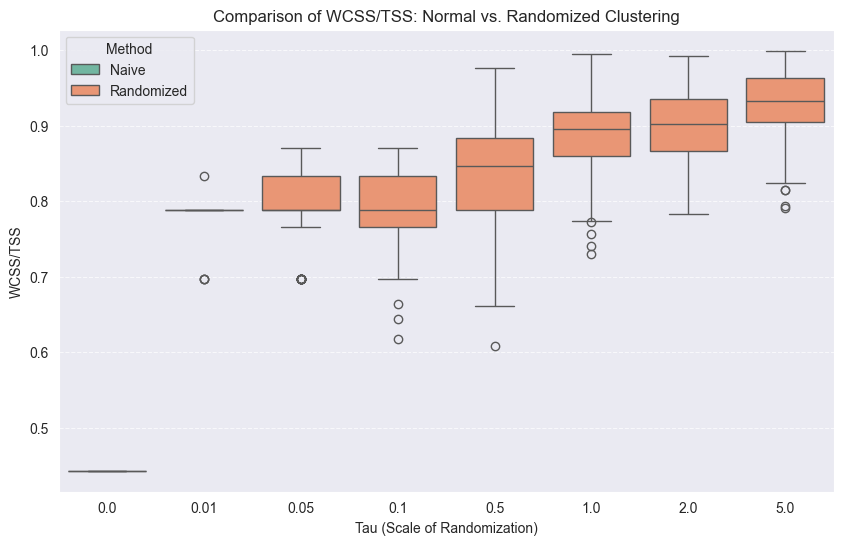

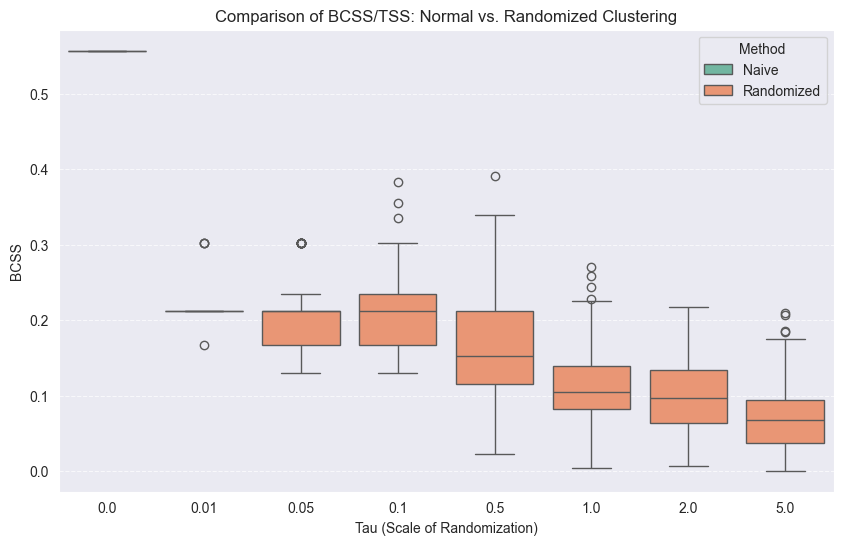

In [2]:
random.seed(42)
n = 30
p = 2
mu = np.zeros(p)
sigma = 1
tau_values = [0,0.01,0.05, 0.1,0.5,1,2,5]
n_runs = 100
n_clusters = 3
# Data collection
results = []
bcss = []
X = generate_null_data(n,p,mu,sigma)
for tau in tau_values:
    for _ in range(n_runs):
        #X, y = make_blobs(n_samples=n, centers=3, cluster_std=1)
        #X, y = generate_data_barbers(10,6,1)
        tss = np.sum((X - np.mean(X, axis=0)) ** 2)
        if tau != 0:
            # Randomized hierarchical clustering
            randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            randomized_clustering.fit()
            randomized_score = randomized_clustering.compute_wcss()
            bcss_score = randomized_clustering.compute_bcss()
            results.append({'Tau': tau, 'Method': 'Randomized', 'WCSS/TSS': randomized_score / tss})
            bcss.append({'Tau': tau, 'Method': 'Randomized', 'BCSS/TSS': bcss_score / tss})
        else:
            naive = cluster.AgglomerativeClustering(n_clusters=n_clusters)
            naive_labels = naive.fit_predict(X)
            naive_score = 0
            for k in range(n_clusters):
                cluster_points = X[naive_labels == k]
                if len(cluster_points) > 0:
                    center = np.mean(cluster_points, axis=0)
                    naive_score += np.sum((cluster_points - center) ** 2)
            results.append({'Tau': tau, 'Method': "Naive", 'WCSS/TSS': naive_score / tss})
            bcss.append({'Tau': tau, 'Method': "Naive", 'BCSS/TSS': (tss - naive_score) / tss})

# Convert results to a DataFrame
df = pd.DataFrame(results)
df_bcss = pd.DataFrame(bcss)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='WCSS/TSS', hue='Method', palette='Set2')
plt.title('Comparison of WCSS/TSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('WCSS/TSS')
plt.legend(title='Method',loc = 'upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_bcss, x='Tau', y='BCSS/TSS', hue='Method', palette='Set2')
plt.title('Comparison of BCSS/TSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('BCSS')
plt.legend(title='Method',loc = 'upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [3]:
med = (
    df.groupby(['Tau','Method'])['WCSS/TSS']
      .median()
      .unstack('Method')
      .rename(columns={'Naive':'Naive_median','Randomized':'Rand_median'})
      .reset_index()
      .sort_values('Tau')
)
rand_curve = (
    med.loc[med['Tau']>0, ['Tau','Rand_median']]
    .copy()
    .sort_values('Tau')
)

taus = rand_curve['Tau'].to_numpy()
ys   = rand_curve['Rand_median'].to_numpy()

def pick_tau_by_max_adjacent_gap(taus, ys):
    gaps = np.abs(np.diff(ys))
    idx = np.argmax(gaps)
    return taus[idx], {'gap': float(gaps[idx])}


tau_gap, info_gap = pick_tau_by_max_adjacent_gap(taus, ys)
print(f"τ* = {tau_gap}, max_gap = {info_gap['gap']:.4f}")

τ* = 0.1, max_gap = 0.0592


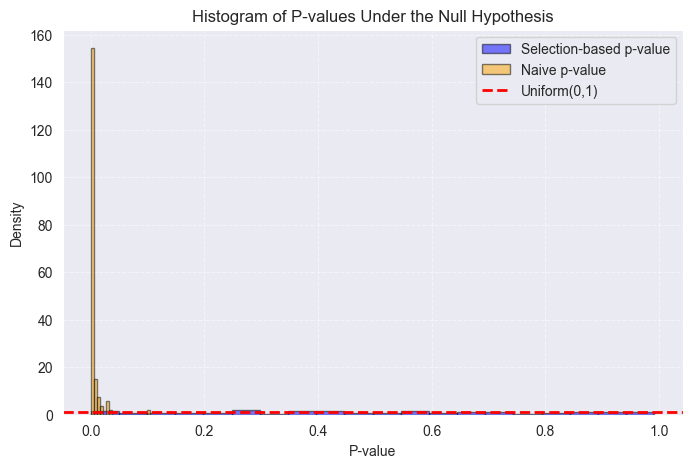

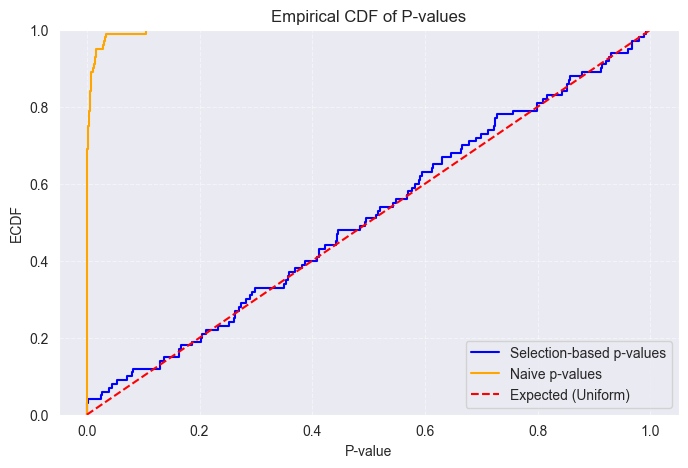

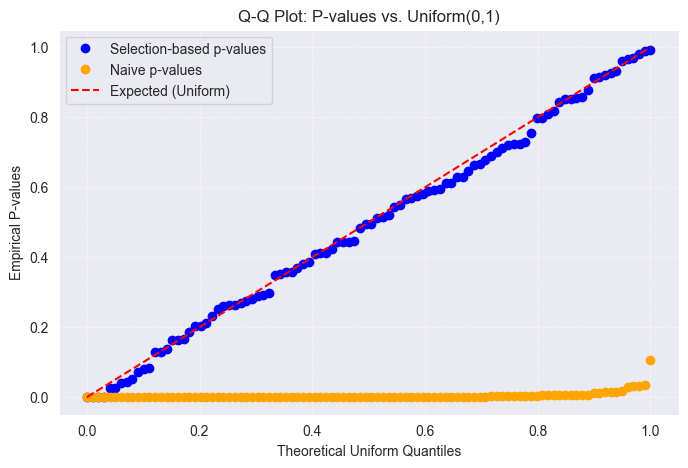

In [4]:
check_p_value_uniformity(n,p,sigma,n_clusters,tau_gap,-1,num_trials=100)

In [11]:
def check_p_value_uniformity_sameX(X, n, p, sigma, K, tau, layer, linkage="complete", num_trials=100):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)
    while len(p_values_n) < num_trials:
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage=linkage)
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs, sel_corrected = model.merge_inference_F(node, grid_width=35, ncoarse=20, ngrid=2000)
        p_value_n = naive_p_value(X, K, layer, linkage)
        if not (np.isnan(p_value) and np.isnan(p_value_n)):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


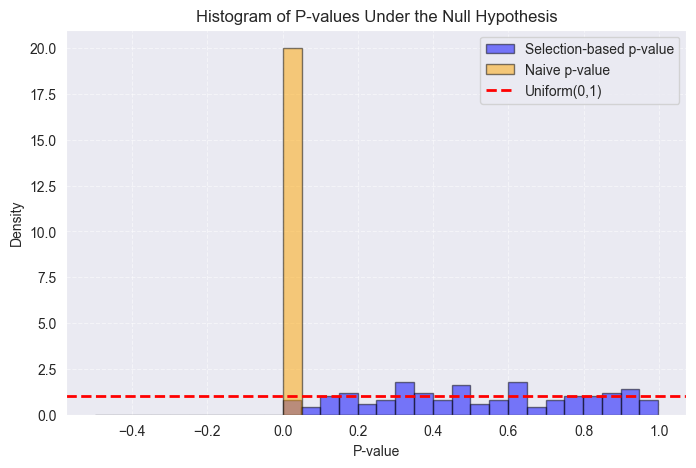

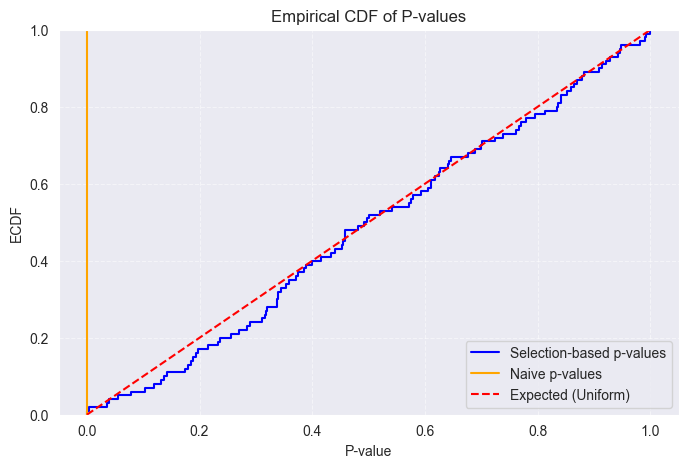

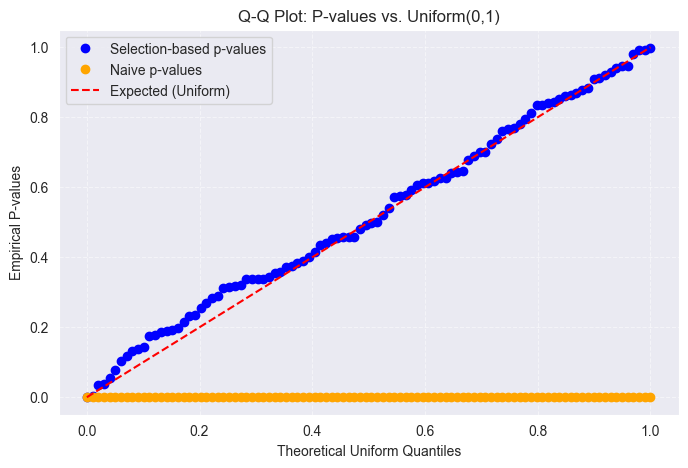

In [12]:
check_p_value_uniformity_sameX(X,n,p,sigma,n_clusters,tau_gap,-1)